In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from utils.plotTools import saving_manager, darken_color

In [46]:
## importing simulation results
run_results_folderpath = r'..\results\1.0'
plot_dir = fr'..\plots\single_run\blabla'

temporal_series_filepath = os.path.join(run_results_folderpath, 'temporal_series_recorder.csv')
simulation_recorder_filepath = os.path.join(run_results_folderpath, 'simulation_recorder.csv')
volcanic_recorder_filepath = os.path.join(run_results_folderpath, 'volcanic_recorder.csv')

In [47]:
## processing temporal dataframe to be more human-readable
temporal_df = pd.read_csv(temporal_series_filepath)
# with pd.option_context('display.width', 1000, 'display.max_columns', None):
#     print(temporal_df)

# TODO: add all correct columns and think about emotion values which are trickier
columns_to_process = ['nb_people_warned', 'nb_people_prepared', 'nb_people_at_port', 'nb_people_who_left_the_island']
for column_name in columns_to_process:
    temporal_df[column_name] = temporal_df['nb_evacuated_people'] + temporal_df[column_name]

##adding ratios
temporal_df['ratio_going_to_port'] = np.where((temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']) != 0, temporal_df['nb_people_going_to_port'] / (temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']), np.nan)
temporal_df['ratio_rescuing_others'] = np.where((temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']) != 0, temporal_df['nb_people_rescuing_others'] / (temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']), np.nan)
temporal_df['ratio_waiting'] = np.where((temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']) != 0, temporal_df['nb_people_waiting'] / (temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']), np.nan)
temporal_df['ratio_fearful'] = np.where((temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']) != 0, temporal_df['nb_fearful_people'] / (temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']), np.nan)
temporal_df['ratio_joyous'] = np.where((temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']) != 0, temporal_df['nb_joyous_people'] / (temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']), np.nan)
temporal_df['ratio_alright'] = np.where((temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']) != 0, temporal_df['nb_alright_people'] / (temporal_df['nb_people_on_island'] + temporal_df['nb_people_on_board']), np.nan)

with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(temporal_df)

# from IPython.display import display
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(temporal_df)

        time  nb_humans_on_island  nb_people_on_island  nb_LEAs_on_island  nb_humans_on_board  nb_people_on_board  nb_LEAs_on_board  nb_evacuated_humans  nb_evacuated_people  nb_evacuated_LEAs  nb_people_warned  nb_people_prepared  nb_people_going_to_port  nb_people_rescuing_others  nb_people_waiting  nb_people_at_port  nb_people_who_left_the_island  nb_joyous_people  nb_fearful_people  nb_alright_people  ratio_going_to_port  ratio_rescuing_others  ratio_waiting  ratio_fearful  ratio_joyous  ratio_alright
0        0.0                   70                   50                 20                   0                   0                 0                    0                    0                  0                 0                   0                        0                          0                  0                  0                              0                 0                  0                  0                 0.00                    0.0            0.0            0.0        

In [48]:
simulation_df = pd.read_csv(simulation_recorder_filepath)
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(simulation_df)
    print('-'*115)

volcanic_df = pd.read_csv(volcanic_recorder_filepath)
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(volcanic_df.head())

   event_time                                    event_name                                              notes
0           0                      Volcanic Activity Update     Volcano LaFossawent from activity level 1 to 2
1           0     Population Evacuation Order - LEAs issued  Civil defense ordered LEAs to issue evacuation...
2          59                       Backups Reached Vulcano  20 backup LEAs arrived on the Island. Ordered ...
3          59     Population Evacuation Order - LEAs issued  Civil defense ordered LEAs to issue evacuation...
4        5597  Population Evacuation Order - LEAs fulfilled  The evacuation order of civil population issui...
5        5625                         LEAs Evacuation Order  Civil defense ordered evacuation of Law Enforc...
6        9346                    Civil Evacuation Completed  The evacuation of civil population was completed.
7       10365                          Evacuation Completed                          Evacuation was completed.
-

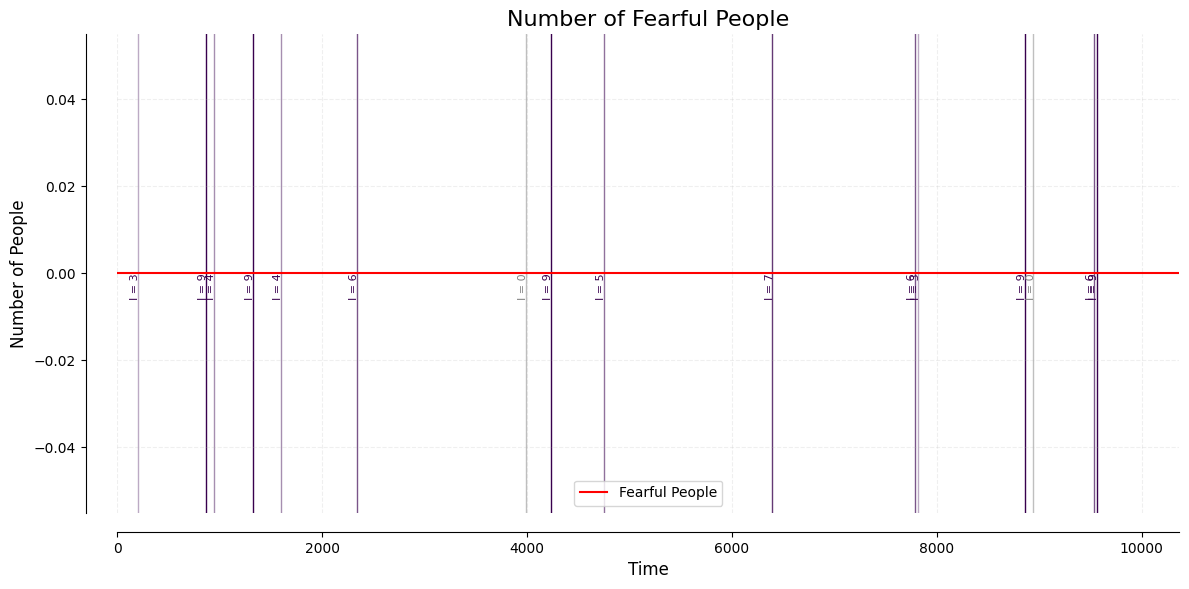

Plot not saved. Remember to set should_save to True if you want to save it.


In [88]:
boom_color = "#38004E"
fear_color = 'red'
#invece del numero assoluto forse meglio plottare il ratio con il numero di persone sull'isola+quelle imbarcate

make_it_fancy = True


plt.figure(figsize=(12, 6))
plt.plot(temporal_df['time'], temporal_df['nb_fearful_people'], label='Fearful People', color=fear_color)

boom_emissions = volcanic_df[volcanic_df['activity_name'] == 'Boom Emission']

max_y = temporal_df['nb_fearful_people'].max() * 1.05
y_coords = [max_y, max_y * 0.95, max_y * 0.9]

for i, row in boom_emissions.iterrows():
    event_time = row['event_time']
    alpha_value = row['activity_intensity_value']/9
    y_coord = y_coords[i % len(y_coords)]
    if alpha_value == 0:
        plt.axvline(x=event_time, color='grey', linestyle='-', alpha=0.5, linewidth=1, zorder=0)
        plt.text(event_time-25, y_coord, f"I = {row['activity_intensity_value']}", 
                rotation=90, va='top', ha='center', fontsize=8, color='grey')

    else:
        plt.axvline(x=event_time, color=boom_color, linestyle='-', alpha=alpha_value, linewidth=1, zorder=0)
        plt.text(event_time-25, y_coord, f"I = {row['activity_intensity_value']}", 
                rotation=90, va='top', ha='center', fontsize=8, color=boom_color)


plt.title('Number of Fearful People', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xlim(0, temporal_df['time'].max())
plt.legend()
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()

if make_it_fancy:
    ax = plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['bottom'].set_position(('axes', -0.04))
    ax.spines['left'].set_position(('axes', -0.03))
plt.tight_layout()

if make_it_fancy:
    plot_filename="fear_evolution" + "_fancy.png"
else:
    plot_filename="fear_evolution" + ".png"
plot_filepath=os.path.join(plot_dir, plot_filename)
saving_manager(should_save=False, save_path=plot_filepath, should_show=True)

In [50]:
series_color = {
    "nb_humans_on_island": "#A52A2A",
    "nb_people_on_island": "#D2691E",
    "nb_LEAs_on_island": "#A0522D",
    "nb_humans_on_board": "#000080",
    "nb_people_on_board": "#4682B4",
    "nb_LEAs_on_board": "#87CEEB",
    "nb_evacuated_humans": "#006400",
    "nb_evacuated_people": "#228B22",
    "nb_evacuated_LEAs": "#3CB371",
    "nb_people_warned": "#ffea00",
    "nb_people_prepared": "#f97c00",
    "nb_people_going_to_port": "#d62728",
    "nb_people_rescuing_others": "#e377c2",
    "nb_people_waiting": "#c7c7c7",
    "nb_people_at_port": "#2284bd",
    "nb_people_who_left_the_island": "#79a2ba",
    "nb_joyous_people": "#b4e05b",
    "nb_fearful_people": "#ff0000",
    "nb_alright_people": "#008080",
}

series_color['ratio_going_to_port'] = series_color['nb_people_going_to_port']
series_color['ratio_rescuing_others'] = series_color['nb_people_rescuing_others']
series_color['ratio_waiting'] = series_color['nb_people_waiting']
series_color['ratio_joyous'] = series_color['nb_joyous_people']
series_color['ratio_fearful'] = series_color['nb_fearful_people']
series_color['ratio_alright'] = series_color['nb_alright_people']

series_label = {
    "nb_people_warned": "Warned",
    "nb_people_prepared": "Prepared",
    "nb_people_going_to_port": "Going to Ports",
    "nb_people_rescuing_others": "Rescuing Others",
    "nb_people_waiting": "Waiting Others",
    "nb_people_at_port": "At Port",
    "nb_people_who_left_the_island": "Left the Island",
    "nb_evacuated_people": "Succesfully Evacuated"
}

series_label['ratio_going_to_port'] = series_label['nb_people_going_to_port']
series_label['ratio_rescuing_others'] = series_label['nb_people_rescuing_others']
series_label['ratio_waiting'] = series_label['nb_people_waiting']
# series_label['ratio_joyous'] = series_label['nb_joyous_people']
# series_label['ratio_fearful'] = series_label['nb_fearful_people']
# series_label['ratio_alright'] = series_label['nb_alright_people']

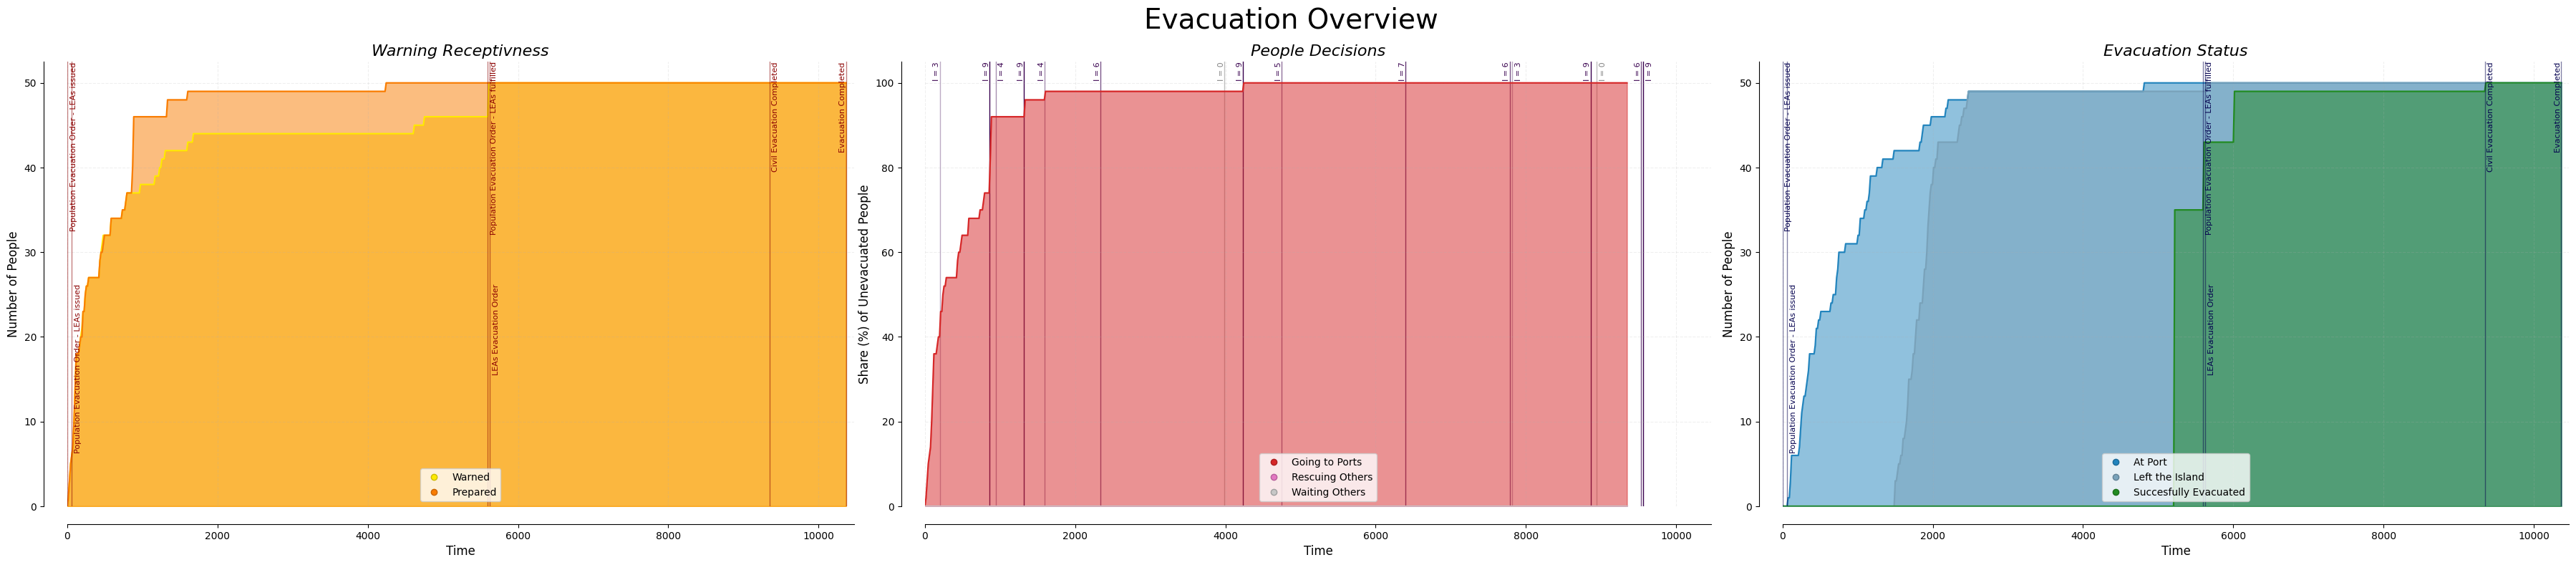

Plot not saved. Remember to set should_save to True if you want to save it.


In [90]:
#invece del numero assoluto forse meglio plottare il ratio con il numero di persone sull'isola+quelle imbarcate

make_it_fancy = True



plots_dict = {
    'Warning Receptivness': {
        'series': ['nb_people_warned', 'nb_people_prepared'],
        'title': "Warning Receptivness",
        'filename': "warning_receptivness",
    },
    'People Decisions': {
        'series': ['ratio_going_to_port', 'ratio_rescuing_others', 'ratio_waiting'],
        'title': "People Decisions",
        'filename': "people_decisions",
    },
    'Evacuation Status': {
        'series': ['nb_people_at_port', 'nb_people_who_left_the_island', 'nb_evacuated_people'],
        'title': "Evacuation Status",
        'filename': "evacuation_status",
    },
}

fig, axes = plt.subplots(1, len(plots_dict), figsize=(12*len(plots_dict), 8))
axes = axes.flatten()


for i, (key, plot_data) in enumerate(plots_dict.items()):
    ax = axes[i]

    area_alpha_value = 0.5

    is_ratio_plot = 'ratio' in plot_data['series'][0]
    if is_ratio_plot:
        for series in plot_data['series']:
            ax.plot([], [], 'o', color=series_color[series], label=series_label[series], markeredgecolor=darken_color(series_color[series]))
            ax.plot(temporal_df['time'], temporal_df[series]*100, color=series_color[series], zorder = 2)
            ax.fill_between(temporal_df['time'], temporal_df[series]*100, color=series_color[series], alpha=area_alpha_value, zorder = 1)
        max_y = 105
        y_coords = [max_y, max_y * 0.95, max_y * 0.9]
        ax.set_ylabel('Share (%) of Unevacuated People', fontsize=12)  
    else:
        for series in plot_data['series']:
            ax.plot([], [], 'o', color=series_color[series], label=series_label[series], markeredgecolor=darken_color(series_color[series]))
            ax.plot(temporal_df['time'], temporal_df[series], color=series_color[series], zorder = 2)
            ax.fill_between(temporal_df['time'], temporal_df[series], color=series_color[series], alpha=area_alpha_value, zorder = 1)
        max_y = temporal_df['nb_people_warned'].max() * 1.05
        ax.set_ylabel('Number of People', fontsize=12)  

    if plot_data['title'] == "Warning Receptivness" or plot_data["title"]=="Evacuation Status":
        evacuation_events = simulation_df[simulation_df['event_name'].str.contains('Evacuation', case=False, na=False)]
        if plot_data['title'] == "Warning Receptivness":
            info_color = 'darkred'
        elif plot_data["title"]=="Evacuation Status":
            info_color = "#03004E"
        previous_event_time = None
        current_y_coords_index = 0
        y_coords = [max_y, max_y*0.5]
        threshold_time = temporal_df['time'].max()*0.02
        for i, row in evacuation_events.iterrows():
            event_time = row['event_time']
            event_name = row['event_name']
            alpha_value = 0.5
            ax.axvline(x=event_time, color=info_color, linestyle='-', alpha=alpha_value, linewidth=1, zorder=3)
            #setting up text position: y-axis
            if previous_event_time is not None:
                time_distance = event_time - previous_event_time
            else:
                time_distance = float('inf')
            if time_distance < threshold_time:
                current_y_coords_index = (current_y_coords_index + 1) % len(y_coords)
            else:
                current_y_coords_index = 0
            y_coord=y_coords[current_y_coords_index]
            previous_event_time = event_time
            #setting up text position: x-axis
            text_offset = temporal_df['time'].max()*0.004
            if event_name == "Evacuation Completed":
                text_position = event_time - text_offset
            else:
                text_position = event_time + text_offset*2
            ax.text(text_position, y_coord, f"{event_name}", 
                    rotation=90, va='top', ha='center', fontsize=8, color=info_color)

    if plot_data['title'] == "People Decisions":
        boom_emissions = volcanic_df[volcanic_df['activity_name'] == 'Boom Emission']
        previous_event_time = None
        current_y_coords_index = 0
        y_coords = [max_y, max_y, max_y * 0.95]
        x_off = temporal_df['time'].max()*0.004
        x_offsets = [-x_off, 2*x_off, -x_off]

        threshold_time = temporal_df['time'].max()*0.02
        for i, row in boom_emissions.iterrows():
            event_time = row['event_time']
            alpha_value = row['activity_intensity_value']/9
            #setting up text 
            if previous_event_time is not None:
                time_distance = event_time - previous_event_time
            else:
                time_distance = float('inf')
            if time_distance < threshold_time:
                current_y_coords_index = (current_y_coords_index + 1) % len(y_coords)
            else:
                current_y_coords_index = 0
            y_coord=y_coords[current_y_coords_index]
            previous_event_time = event_time
            text_x_offset=x_offsets[current_y_coords_index]
            if alpha_value == 0:
                ax.axvline(x=event_time, color='grey', linestyle='-', alpha=0.5, linewidth=1, zorder=0)
                ax.text(event_time+text_x_offset, y_coord, f"I = {row['activity_intensity_value']}", 
                        rotation=90, va='top', ha='center', fontsize=8, color='grey')
            else:
                ax.axvline(x=event_time, color=boom_color, linestyle='-', alpha=alpha_value, linewidth=1, zorder=0)
                ax.text(event_time+text_x_offset, y_coord, f"I = {row['activity_intensity_value']}", 
                        rotation=90, va='top', ha='center', fontsize=8, color=boom_color)


    ax.set_title(plot_data['title'], fontsize=16, fontstyle='italic')
    ax.set_xlabel('Time', fontsize=12)
    ax.set_xlim(0, temporal_df['time'].max()*1.01)
    ax.set_ylim(0)
    ax.legend(loc='lower center')
    ax.grid(True, linestyle='--', alpha=0.2, zorder=4)

    if make_it_fancy:
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        ax.spines['bottom'].set_position(('axes', -0.04))
        ax.spines['left'].set_position(('axes', -0.03))
fig.suptitle("Evacuation Overview", fontsize=28)
fig.tight_layout()

if make_it_fancy:
    plot_filename="people_evacuation_overview" + "_fancy.png"
else:
    plot_filename="people_evacuation_overview" + ".png"
plot_filepath=os.path.join(plot_dir, plot_filename)
saving_manager(should_save=False, save_path=plot_filepath, should_show=True)
